# Traffic Light Classification using VGG16 Transfer Learning

## 1. Import Libraries

In [9]:
import os
import random
import zipfile
import shutil

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Reproducibility Settings

I am using seeds to make the results more consistent across runs.

In [10]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Extract Dataset

The expected dataset structure is:

```text
traffic/
    Green/
    Red/
```

In [11]:
ZIP_PATH = 'traffic.zip'
DATA_DIR = 'traffic'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('.')
print('Dataset extracted successfully.')

print('Dataset folders:', os.listdir(DATA_DIR))

Dataset extracted successfully.
Dataset folders: ['Green', '.DS_Store', 'Red']


## 4. Load Images using OpenCV

OpenCV loads images in **BGR**, while VGG16 preprocessing expects images in the usual **RGB** order.

In [ ]:
IMG_SIZE = 224

X = []
Z = []

GREEN_DIR = os.path.join(DATA_DIR, 'Green')
RED_DIR = os.path.join(DATA_DIR, 'Red')

def assign_label(img, traffic_light_type):
    return traffic_light_type

def make_train_data(traffic_light_type, DIR):
    for img_name in os.listdir(DIR):
        img_path = os.path.join(DIR, img_name)

        try:
            img = cv2.imread(img_path)

            # convert to RGB for VGG16
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize to VGG16 input size
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            Z.append(assign_label(img, traffic_light_type))


make_train_data('Green', GREEN_DIR)
make_train_data('Red', RED_DIR)

X = np.array(X, dtype='float32') 
Z = np.array(Z)

print('X shape:', X.shape)
print('Z shape:', Z.shape)
print('Classes and counts:', pd.Series(Z).value_counts().to_dict())

X shape: (200, 224, 224, 3)
Z shape: (200,)
Classes and counts: {'Green': 100, 'Red': 100}


## 5. Check Loaded Images

Confirming that images are displayed with the correct colour channels after converting from BGR to RGB.

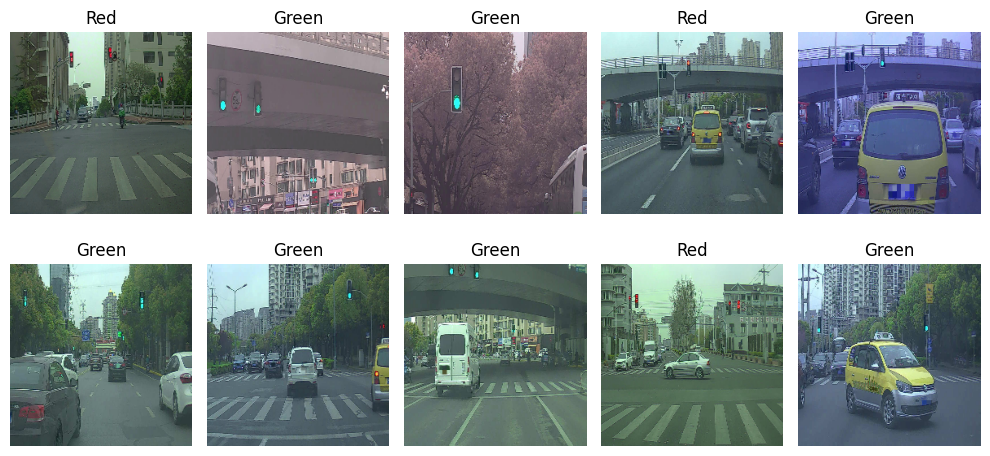

In [13]:
plt.figure(figsize=(10, 5))
for i in range(10):
    idx = random.randint(0, len(X) - 1)
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].astype('uint8'))
    plt.title(Z[idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Encode Labels

In [23]:
le = LabelEncoder()
y_integer = le.fit_transform(Z)
y = to_categorical(y_integer,2)

class_names = list(le.classes_)
print('Class names:', class_names)
print('Encoded label example:', Z[0], '->', y_integer[0], '->', y[0])

Class names: [np.str_('Green'), np.str_('Red')]
Encoded label example: Green -> 0 -> [1. 0.]


## 7. Stratified Train/Validation/Test Split

The dataset is small, so stratification is important to keep Green and Red balanced in each split.

Split used:

- 70% training
- 15% validation
- 15% testing

In [35]:
X_train, X_temp, y_train, y_temp, y_train_int, y_temp_int = train_test_split(
    X,
    y,
    y_integer,
    test_size=0.30,
    random_state=SEED,
    stratify=y_integer
)

X_val, X_test, y_val, y_test, y_val_int, y_test_int = train_test_split(
    X_temp,
    y_temp,
    y_temp_int,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_int
)

print('Training:', X_train.shape, pd.Series(y_train_int).value_counts().sort_index().to_dict())
print('Validation:', X_val.shape, pd.Series(y_val_int).value_counts().sort_index().to_dict())
print('Testing:', X_test.shape, pd.Series(y_test_int).value_counts().sort_index().to_dict())

Training: (140, 224, 224, 3) {0: 70, 1: 70}
Validation: (30, 224, 224, 3) {0: 15, 1: 15}
Testing: (30, 224, 224, 3) {0: 15, 1: 15}


## 8. Helper Functions

In [36]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'{model_name} test accuracy: {test_acc:.4f}')
    print(f'{model_name} test loss: {test_loss:.4f}')

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(f'Classification report for {model_name}:')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return test_loss, test_acc, y_true, y_pred, y_pred_probs

## 9. Data Augmentation

Data augmentation is applied inside the model, so it runs only during training.

In [37]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name='data_augmentation')

# Model 1: Frozen VGG16 + Data Augmentation


In [38]:
base_model_1 = VGG16(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_1.trainable = False

model_1 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model_1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(2, activation='softmax')
])

model_1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [39]:
callbacks_1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

history_1 = model_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=16,
    callbacks=callbacks_1,
    verbose=1
)

Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6518 - loss: 1.3218 - val_accuracy: 0.6000 - val_loss: 1.6742
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5700 - loss: 1.6619 - val_accuracy: 0.6000 - val_loss: 1.4178
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6540 - loss: 1.1417 - val_accuracy: 0.5667 - val_loss: 1.6294
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5590 - loss: 1.2693 - val_accuracy: 0.5667 - val_loss: 1.5289
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6906 - loss: 1.0316 - val_accuracy: 0.6000 - val_loss: 1.2937
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6145 - loss: 1.1221 - val_accuracy: 0.6000 - val_loss: 1.1346
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6473 - loss: 0.9843 - val_accuracy: 0.6667 - val_loss: 0.9520
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6979 - loss: 0.9468 - val_accuracy: 0.6667 - val_loss: 0.8559
Epoch 9/

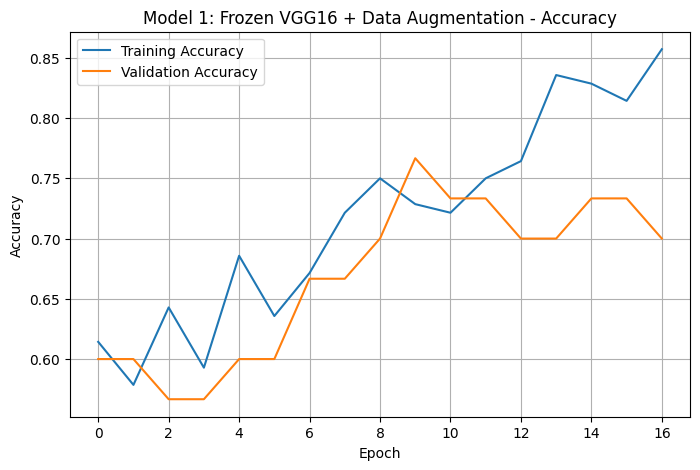

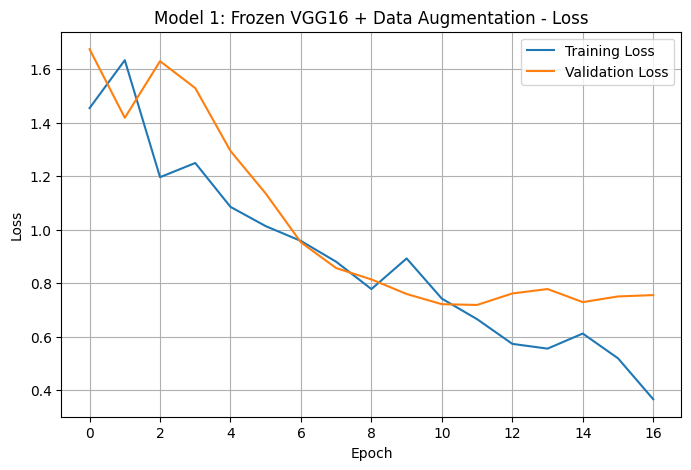

Model 1 VGG16 Baseline test accuracy: 0.8333
Model 1 VGG16 Baseline test loss: 0.3265
Classification report for Model 1 VGG16 Baseline:
              precision    recall  f1-score   support

       Green       0.86      0.80      0.83        15
         Red       0.81      0.87      0.84        15

    accuracy                           0.83        30
   macro avg       0.83      0.83      0.83        30
weighted avg       0.83      0.83      0.83        30



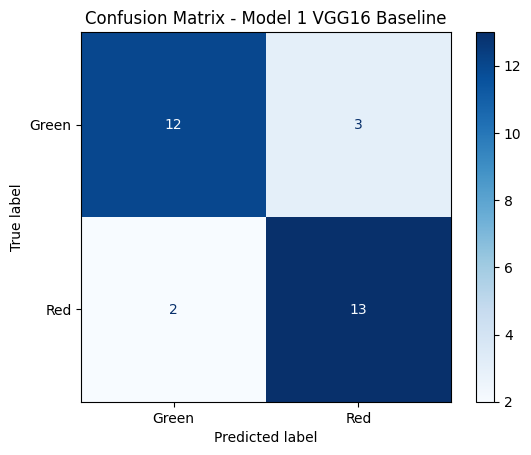

In [40]:
plot_history(history_1, 'Model 1: Frozen VGG16 + Data Augmentation')
model_1_loss, model_1_acc, y_true_1, y_pred_1, y_pred_probs_1 = evaluate_model(
    model_1, X_test, y_test, 'Model 1 VGG16 Baseline'
)

# Model 2: VGG16 + Stronger Regularisation

Improvement Method 1 adds stronger regularisation:

- L2 regularisation
- Higher dropout

This aims to reduce overfitting and improve generalisation.

In [80]:
base_model_2 = VGG16(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_2.trainable = False

model_2 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model_2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.50),
    layers.Dense(2, activation='softmax')
])

model_2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_7 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [81]:
callbacks_2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    )
]

history_2 = model_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=callbacks_2,
    verbose=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5536 - loss: 1.9925 - val_accuracy: 0.5000 - val_loss: 1.9735
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5474 - loss: 2.0108 - val_accuracy: 0.5667 - val_loss: 1.8175
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6062 - loss: 1.5237 - val_accuracy: 0.6333 - val_loss: 1.7114
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5823 - loss: 1.2515 - val_accuracy: 0.6333 - val_loss: 1.6308
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5419 - loss: 1.4804 - val_accuracy: 0.6333 - val_loss: 1.6810
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6835 - loss: 1.1853 - val_accuracy: 0.6333 - val_loss: 1.5984
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5937 - loss: 1.3008 - val_accuracy: 0.6333 - val_loss: 1.6328
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6455 - loss: 1.1801 - val_accuracy: 0.6333 - val_loss: 1.6627
Epoch 9/

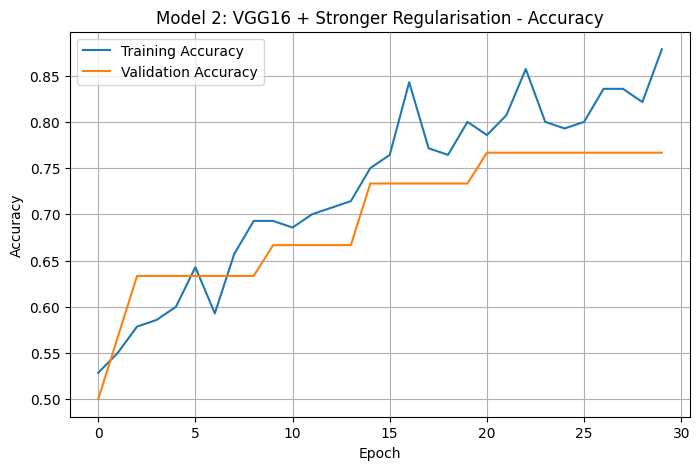

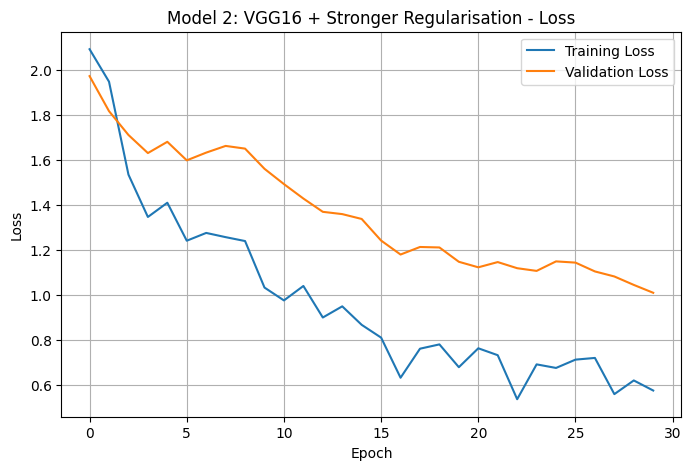

Model 2 Regularised VGG16 test accuracy: 0.9000
Model 2 Regularised VGG16 test loss: 0.4816
Classification report for Model 2 Regularised VGG16:
              precision    recall  f1-score   support

       Green       1.00      0.80      0.89        15
         Red       0.83      1.00      0.91        15

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



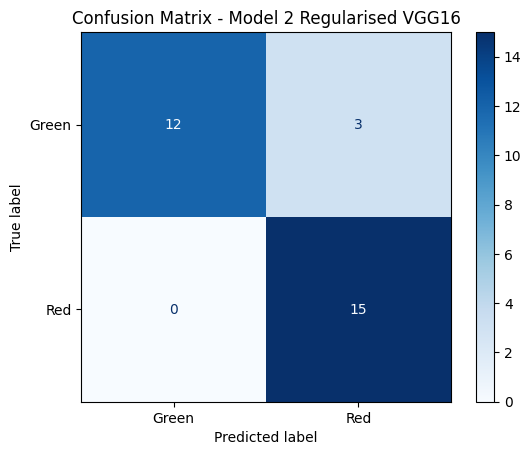

In [82]:
plot_history(history_2, 'Model 2: VGG16 + Stronger Regularisation')
model_2_loss, model_2_acc, y_true_2, y_pred_2, y_pred_probs_2 = evaluate_model(
    model_2, X_test, y_test, 'Model 2 Regularised VGG16'
)

# Model 3: Classification Threshold Tuning

Getting validation probabilities

In [70]:
val_probs = model_1.predict(X_val)

y_val_true = np.argmax(y_val, axis=1)

print(val_probs[:5])
print(y_val_true[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[9.9980128e-01 1.9864866e-04]
 [7.9293698e-03 9.9207062e-01]
 [9.9030894e-01 9.6910810e-03]
 [8.6068922e-01 1.3931088e-01]
 [3.7822712e-02 9.6217734e-01]]
[0 1 0 0 0]


Testing different Red thresholds

In [71]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

threshold_results = []

for threshold in np.arange(0.30, 0.76, 0.05):

    # Predict Red only if Red probability is at least the threshold.
    # Otherwise predict Green.
    y_val_pred = np.where(val_probs[:, 1] >= threshold, 1, 0)

    acc = accuracy_score(y_val_true, y_val_pred)
    precision = precision_score(y_val_true, y_val_pred, average="macro", zero_division=0)
    recall = recall_score(y_val_true, y_val_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_val_true, y_val_pred, average="macro")

    cm = confusion_matrix(y_val_true, y_val_pred)

    threshold_results.append({
        "Red Threshold": round(threshold, 2),
        "Validation Accuracy": round(acc, 4),
        "Validation Precision": round(precision, 4),
        "Validation Recall": round(recall, 4),
        "Validation Macro F1": round(macro_f1, 4),
        "Green predicted as Red": cm[0, 1],
        "Red predicted as Green": cm[1, 0]
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Red Threshold,Validation Accuracy,Validation Precision,Validation Recall,Validation Macro F1,Green predicted as Red,Red predicted as Green
0,0.30,0.6667,0.7329,0.6667,0.6411,9,1
1,0.35,0.7000,0.7557,0.7000,0.6827,8,1
2,0.40,0.7000,0.7557,0.7000,0.6827,8,1
3,0.45,0.7000,0.7557,0.7000,0.6827,8,1
4,0.50,0.7333,0.7778,0.7333,0.7222,7,1
5,0.55,0.7333,0.7778,0.7333,0.7222,7,1
6,0.60,0.7667,0.8000,0.7667,0.7600,6,1
7,0.65,0.7667,0.8000,0.7667,0.7600,6,1
8,0.70,0.8667,0.8733,0.8667,0.8661,3,1
9,0.75,0.8667,0.8733,0.8667,0.8661,3,1


Selecting the best threshold

In [72]:
best_threshold_row = threshold_df.sort_values(
    by=["Validation Macro F1", "Validation Accuracy"],
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["Red Threshold"]

print("Best threshold:")
print(best_threshold_row)

Best threshold:
Red Threshold             0.7000
Validation Accuracy       0.8667
Validation Precision      0.8733
Validation Recall         0.8667
Validation Macro F1       0.8661
Green predicted as Red    3.0000
Red predicted as Green    1.0000
Name: 8, dtype: float64


Applying the threshold to the test set

In [73]:
test_probs = model_1.predict(X_test)

y_test_true = np.argmax(y_test, axis=1)

y_test_pred_threshold = np.where(test_probs[:, 1] >= best_threshold, 1, 0)

threshold_test_accuracy = accuracy_score(y_test_true, y_test_pred_threshold)
threshold_test_precision = precision_score(y_test_true, y_test_pred_threshold, average="macro", zero_division=0)
threshold_test_recall = recall_score(y_test_true, y_test_pred_threshold, average="macro", zero_division=0)
threshold_test_macro_f1 = f1_score(y_test_true, y_test_pred_threshold, average="macro")

print(f"Best Red threshold: {best_threshold}")
print(f"Threshold-tuned test accuracy: {threshold_test_accuracy:.4f}")
print(f"Threshold-tuned macro precision: {threshold_test_precision:.4f}")
print(f"Threshold-tuned macro recall: {threshold_test_recall:.4f}")
print(f"Threshold-tuned macro F1-score: {threshold_test_macro_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Best Red threshold: 0.7
Threshold-tuned test accuracy: 0.8667
Threshold-tuned macro precision: 0.8667
Threshold-tuned macro recall: 0.8667
Threshold-tuned macro F1-score: 0.8667


Plot threshold performance

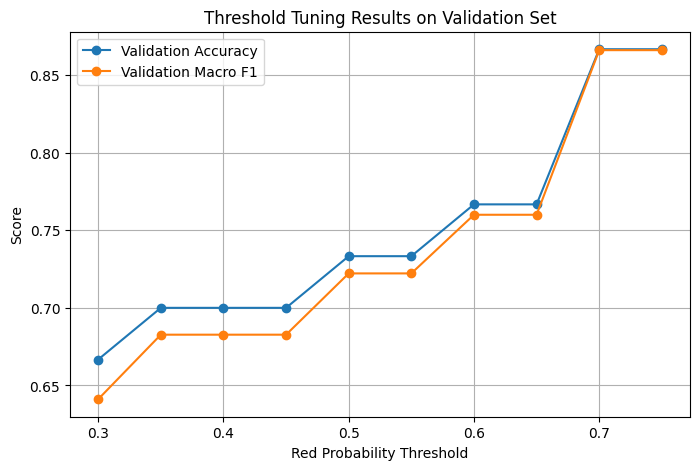

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Validation Macro F1"],
    marker="o",
    label="Validation Macro F1"
)

plt.title("Threshold Tuning Results on Validation Set")
plt.xlabel("Red Probability Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

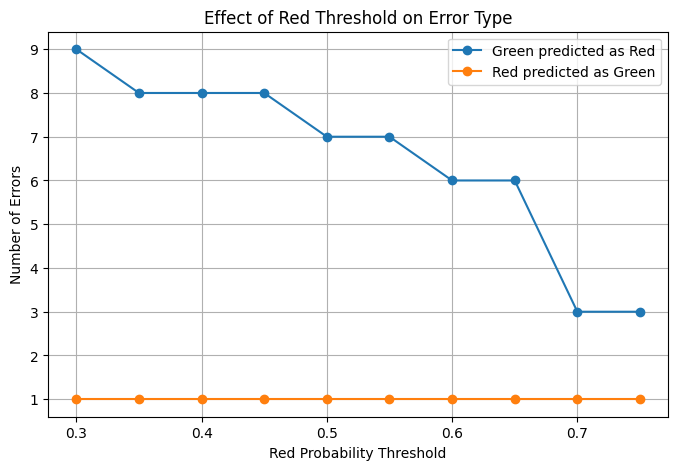

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Green predicted as Red"],
    marker="o",
    label="Green predicted as Red"
)

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Red predicted as Green"],
    marker="o",
    label="Red predicted as Green"
)

plt.title("Effect of Red Threshold on Error Type")
plt.xlabel("Red Probability Threshold")
plt.ylabel("Number of Errors")
plt.legend()
plt.grid(True)
plt.show()

Classification report and confusion matrix

In [74]:
print("Classification report after threshold tuning:")
print(classification_report(
    y_test_true,
    y_test_pred_threshold,
    target_names=class_names
))

Classification report after threshold tuning:
              precision    recall  f1-score   support

       Green       0.87      0.87      0.87        15
         Red       0.87      0.87      0.87        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



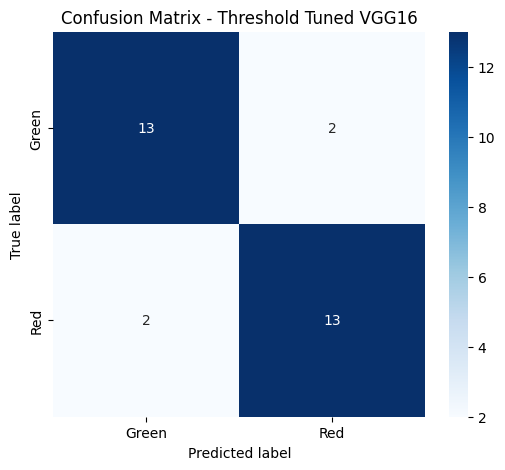

In [75]:
import seaborn as sns

cm_threshold = confusion_matrix(y_test_true, y_test_pred_threshold)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Threshold Tuned VGG16")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

## 10. Compare All Models

In [88]:
comparison_df = pd.DataFrame({
    'Model': [
        'Model 1: Frozen VGG16 + Data Augmentation',
        'Model 2: Regularised VGG16',
        'Model 3: Classification threshold tuning VGG16'
    ],
    'Test Accuracy': [model_1_acc, model_2_acc, threshold_test_accuracy],
})

comparison_df

,Model,Test Accuracy
0,Model 1: Frozen VGG16 + Data Augmentation,0.833333
1,Model 2: Regularised VGG16,0.900000
2,Model 3: Classification threshold tuning VGG16,0.866667


In [89]:
comparison_df.to_csv('model_comparison_results.csv', index=False)
print('Saved: model_comparison_results.csv')

Saved: model_comparison_results.csv


## 11. Five Unseen Test Image Predictions

These images are selected from the test set, not the training set.

By default, this uses the final fine-tuned model. If Model 2 performs best, change `best_model = model_2` is already correct because Model 3 fine-tuning was performed on `model_2`.

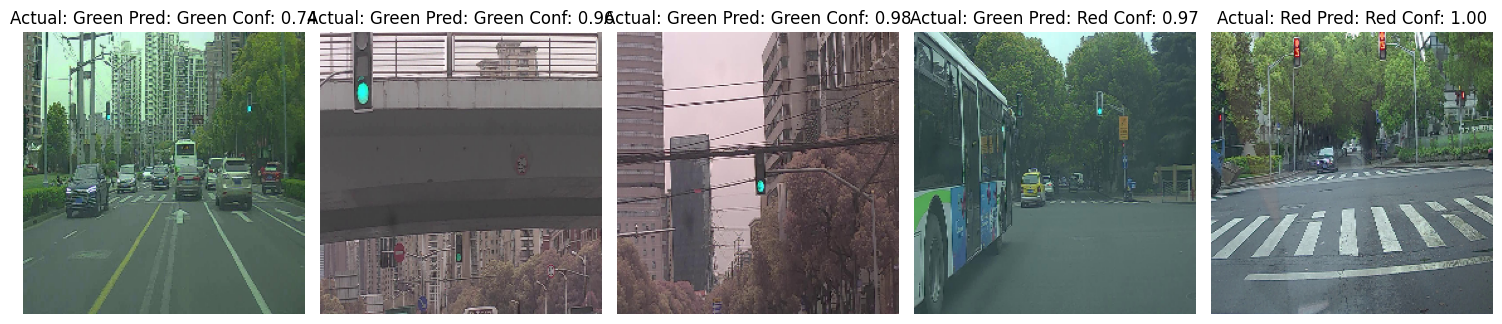

,Image Number,Actual Label,Predicted Label,Confidence
0,1,Green,Green,0.7358
1,2,Green,Green,0.9636
2,3,Green,Green,0.9849
3,4,Green,Red,0.9735
4,5,Red,Red,0.9992


In [90]:
best_model = model_2

prediction_probs = best_model.predict(X_test, verbose=0)
predicted_classes = np.argmax(prediction_probs, axis=1)
actual_classes = np.argmax(y_test, axis=1)

plt.figure(figsize=(15, 6))
five_predictions = []

for i in range(5):
    actual_label = class_names[actual_classes[i]]
    predicted_label = class_names[predicted_classes[i]]
    confidence = prediction_probs[i][predicted_classes[i]]

    five_predictions.append({
        'Image Number': i + 1,
        'Actual Label': actual_label,
        'Predicted Label': predicted_label,
        'Confidence': round(float(confidence), 4)
    })

    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i].astype('uint8'))
    plt.title(f'Actual: {actual_label} Pred: {predicted_label} Conf: {confidence:.2f}')
    plt.axis('off')

plt.tight_layout()
plt.show()

five_predictions_df = pd.DataFrame(five_predictions)
five_predictions_df

## 12. Save Best Model

In [23]:
best_model.save('traffic_light_vgg16_best_model.keras')
print('Saved: traffic_light_vgg16_best_model.keras')

Saved: traffic_light_vgg16_best_model.keras


## Notes for Report Writing

Use the model comparison table, confusion matrices, classification reports, and five-image prediction table in your final report.

If Model 2 performs best, explain that stronger regularisation improved performance and generalisation. If Model 3 does not improve beyond Model 2, explain that fine-tuning was tested but gave no extra gain because the dataset was small.